1.A university wants to predict a student's final examination score based on the number of hours studied.

    X: Number of hours studied
    Y: Final examination score (out of 100)

Using the given dataset, implement Simple Linear Regression by computing the regression coefficients using the

Predict the examination score for a student who studies 9 hours.

Plot the data points and regression line

Slope (b1): 4.976190476190476
Intercept (b0): 39.85714285714286
Predicted score for 9 hours: 84.64285714285714


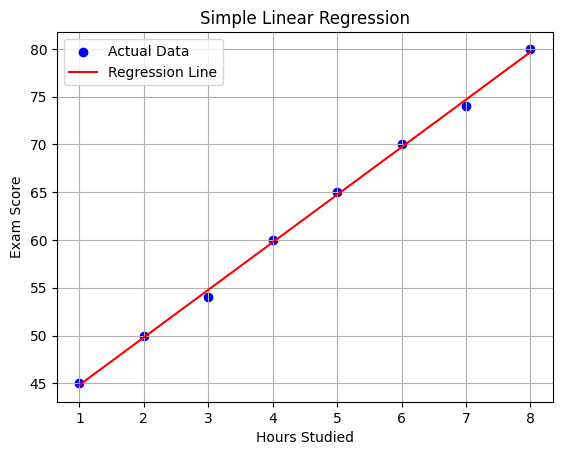

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1,2,3,4,5,6,7,8])
Y = np.array([45,50,54,60,65,70,74,80])
x_mean = np.mean(X)
y_mean = np.mean(Y)

b1 = np.sum((X-x_mean)*(Y-y_mean)) / np.sum((X-x_mean)**2)
b0 = y_mean - b1*x_mean

print("Slope (b1):", b1)
print("Intercept (b0):", b0)

hours = 9
prediction = b0 + b1*hours

print("Predicted score for 9 hours:", prediction)

Y_pred = b0 + b1*X

plt.scatter(X,Y,color="blue",label="Actual Data")
plt.plot(X,Y_pred,color="red",label="Regression Line")

plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.title("Simple Linear Regression")
plt.legend()
plt.grid()
plt.show()

2.A real estate company wants to predict the selling price of a house based on two independent variables:

    X₁: Area of the house (in 1000 sq. ft.)
    X₂: Age of the house (in years)

The selling price (Y) is measured in lakhs of rupees.

Using the given dataset, implement Multiple Linear Regression by computing the regression coefficients using the Normal Equation (Matrix Form).

Predict the price when area is 4 and age is 1

In [ ]:
import numpy as np

X = np.array([[1.0, 10], [1.5, 8], [2.0, 6], [2.5, 5], [3.0, 3], [3.5, 2]])
Y = np.array([20,24,29, 32, 38, 43])
X_b = np.c_[np.ones((X.shape[0],1)), X]
theta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(Y)
area=4
age=1
new_house=np.array([1, area, age])
price=new_house.dot(theta)
print("Predicted Price:", price)

[1.04285714e+01 9.14285714e+00 1.26121336e-13]
Predicted Price: 47.000000000000014


3.A company wants to predict an employee's monthly salary based on years of work experience.

Implement Simple Linear Regression using the Gradient Descent algorithm to determine the best-fit regression line.

plot:

    1. The original data points with the fitted regression line.
    2. The Cost (MSE) vs. Iterations graph to visualize how Gradient Descent converges.

Slope: 7.911730093795043
Intercept:  9.20477048209224


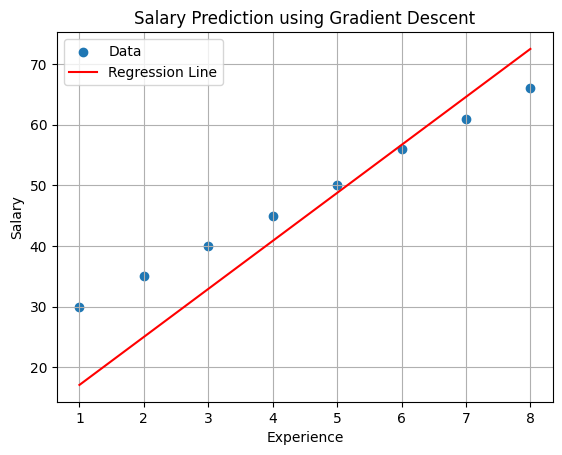

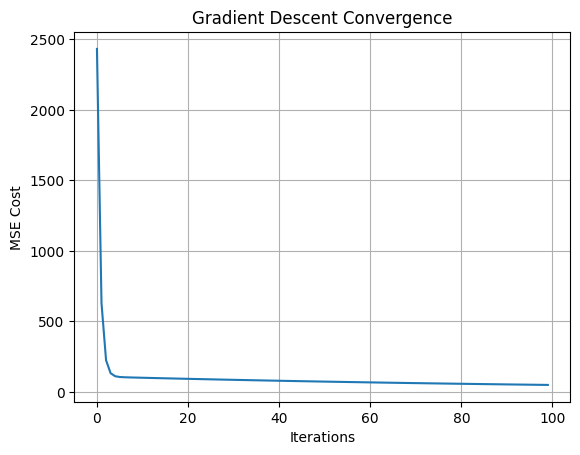

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([1,2,3,4,5,6,7,8])
Y = np.array([30, 35, 40, 45,50,56,61,66])
m=0
c=0
learning_rate=0.01
iterations=100
n=len(X)
cost_history=[]

for i in range(iterations):
  Y_pred=m*X+c
  cost = (1/n)*np.sum((Y-Y_pred)**2)
  cost_history.append(cost)
  dm=(-2/n)*np.sum(X*(Y-Y_pred))
  dc=(-2/n)*np.sum((Y-Y_pred))
  m=m-learning_rate*dm
  c=c-learning_rate*dc
print("Slope:", m)
print("Intercept: ", c)

plt.scatter(X,Y,label="Data")

plt.plot(X,m*X+c,color="red",
         label="Regression Line")

plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Salary Prediction using Gradient Descent")

plt.legend()
plt.grid()
plt.show()
plt.plot(cost_history)

plt.xlabel("Iterations")
plt.ylabel("MSE Cost")

plt.title("Gradient Descent Convergence")

plt.grid()
plt.show()

4.Implement linear regression with one variable on the California Housing dataset to predict housing prices based on a single feature (e.g., the average number of rooms per dwelling).

Tasks:

● Load and preprocess the datase.

● Implement linear regression using both gradient descent and the normal equation.

● Evaluate the model performance using metrics such as Mean Squared Error

(MSE) and R-squared.

● Visualize the fitted line along with the data points.

----- Normal Equation -----
Intercept: 1.6547622685968426
Slope: 0.07675558963126718
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


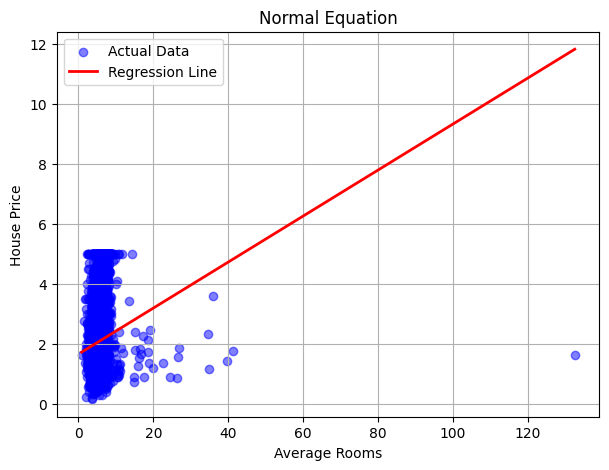


----- Gradient Descent -----
Slope: 0.18323881682652998
Intercept: 2.071946933891858
MSE: 1.2923314439327267
R2 Score: 0.013795337645229111


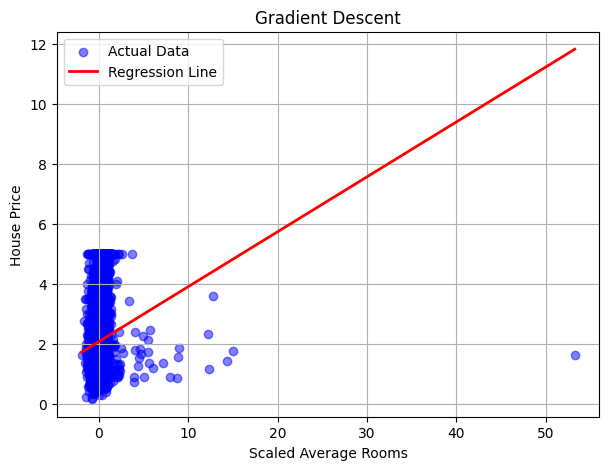

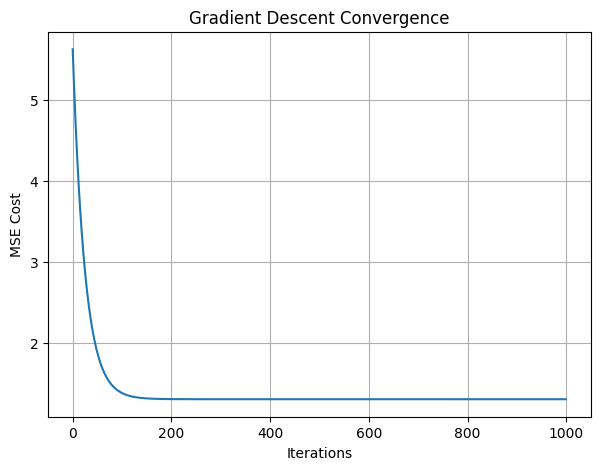

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

housing = fetch_california_housing()
X = housing.data[:, 2].reshape(-1, 1)
Y = housing.target
X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42
)
X_train_b = np.c_[np.ones((X_train.shape[0], 1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0], 1)), X_test]
theta = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(Y_train)

print("----- Normal Equation -----")
print("Intercept:", theta[0])
print("Slope:", theta[1])
Y_pred = X_test_b.dot(theta)
print("MSE:", mean_squared_error(Y_test, Y_pred))
print("R2 Score:", r2_score(Y_test, Y_pred))
sorted_index = np.argsort(X_test[:, 0])

plt.figure(figsize=(7,5))
plt.scatter(X_test, Y_test, color='blue', alpha=0.5, label="Actual Data")
plt.plot(
    X_test[sorted_index],
    Y_pred[sorted_index],
    color='red',
    linewidth=2,
    label="Regression Line"
)
plt.xlabel("Average Rooms")
plt.ylabel("House Price")
plt.title("Normal Equation")
plt.legend()
plt.grid()
plt.show()
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
m = 0
c = 0

learning_rate = 0.01
iterations = 1000

n = len(X_train_scaled)

cost_history = []
for i in range(iterations):

    Y_pred_train = m * X_train_scaled[:,0] + c

    cost = (1/n) * np.sum((Y_train - Y_pred_train)**2)

    cost_history.append(cost)

    dm = (-2/n) * np.sum(X_train_scaled[:,0] * (Y_train - Y_pred_train))
    dc = (-2/n) * np.sum(Y_train - Y_pred_train)

    m = m - learning_rate * dm
    c = c - learning_rate * dc

print("\n----- Gradient Descent -----")
print("Slope:", m)
print("Intercept:", c)
Y_pred_gd = m * X_test_scaled[:,0] + c
print("MSE:", mean_squared_error(Y_test, Y_pred_gd))
print("R2 Score:", r2_score(Y_test, Y_pred_gd))
sorted_index = np.argsort(X_test_scaled[:,0])

plt.figure(figsize=(7,5))
plt.scatter(X_test_scaled, Y_test,
            color='blue',
            alpha=0.5,
            label="Actual Data")

plt.plot(
    X_test_scaled[sorted_index],
    Y_pred_gd[sorted_index],
    color='red',
    linewidth=2,
    label="Regression Line"
)

plt.xlabel("Scaled Average Rooms")
plt.ylabel("House Price")
plt.title("Gradient Descent")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("MSE Cost")
plt.title("Gradient Descent Convergence")
plt.grid()
plt.show()

5.Implement polynomial regression on the Auto MPG dataset to predict miles per gallon (MPG) based on engine displacement. Compare polynomial regression results with linear regression.

Tasks:

    ● Load and preprocess the dataset.

    ● Implement polynomial regression of varying degrees.

    ● Compare the polynomial regression models with linear regression using metrics such as MSE and R-squared.

    ● Visualize the polynomial fit.

Index(['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration',
       'model', 'origin', 'class'],
      dtype='object')
Linear Regression
MSE: 21.227484289611397
R2: 0.5841057656051312

Polynomial Degree: 2
MSE: 20.649054718307305
R2: 0.5954385038809804

Polynomial Degree: 3
MSE: 20.81794078857357
R2: 0.5921296453306659

Polynomial Degree: 4
MSE: 20.88841279063398
R2: 0.5907489400646382

Polynomial Degree: 5
MSE: 20.818592871128562
R2: 0.5921168695645285


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


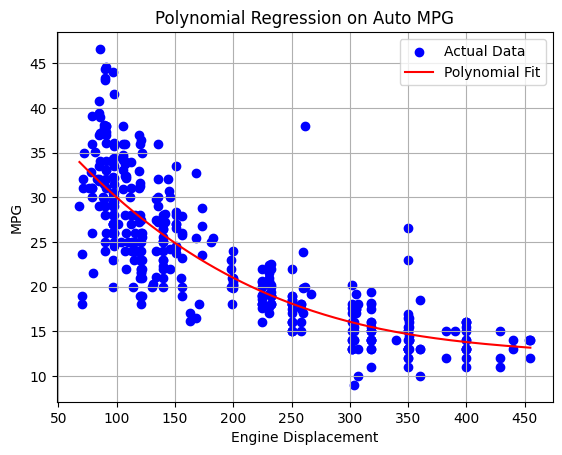

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression

from sklearn.preprocessing import PolynomialFeatures

from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_squared_error,r2_score

auto = fetch_openml(
    name="autoMpg",
    version=1,
    as_frame=True
)

df = auto.frame

df=df.dropna()

X=df[['displacement']]

Y=df['class']

X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42
)

linear_model=LinearRegression()

linear_model.fit(X_train,Y_train)

linear_pred=linear_model.predict(X_test)



print("Linear Regression")

print("MSE:",
mean_squared_error(Y_test,linear_pred))

print("R2:",
r2_score(Y_test,linear_pred))


for degree in [2,3,4,5]:

    poly_model=Pipeline([
        ('poly',
         PolynomialFeatures(degree)),
        ('linear',
         LinearRegression())
    ])


    poly_model.fit(X_train,Y_train)


    pred=poly_model.predict(X_test)


    print("\nPolynomial Degree:",degree)

    print("MSE:",
    mean_squared_error(Y_test,pred))

    print("R2:",
    r2_score(Y_test,pred))

x_range=np.linspace(
    X.min(),
    X.max(),
    200
).reshape(-1,1)


degree=3

poly_model=Pipeline([
    ('poly',
     PolynomialFeatures(degree)),
    ('linear',
     LinearRegression())
])


poly_model.fit(X,Y)


plt.scatter(
    X,Y,
    color="blue",
    label="Actual Data"
)


plt.plot(
    x_range,
    poly_model.predict(x_range),
    color="red",
    label="Polynomial Fit"
)


plt.xlabel("Engine Displacement")
plt.ylabel("MPG")

plt.title("Polynomial Regression on Auto MPG")

plt.legend()
plt.grid()

plt.show()